# TMD-03: Synthetic Text Generation with LLMs
## Teaching Machines to Dream · Engineer's Handbook Series

**Authors:** Aimal Khan · Hamza Raziq Khan  
**Handbook:** Teaching Machines to Dream: A Practical Engineer's Handbook on Synthetic Data

---

This notebook is the companion to **Chapter 4: Synthetic Text Data** of the handbook.

### The Problem

Labeled text datasets are expensive and slow to create. A sentiment analysis
model needs thousands of labeled reviews. A customer support classifier needs
hundreds of annotated conversations. Collecting and labeling this data takes
weeks and costs money.

Large language models solve this. We can generate thousands of realistic,
labeled text samples in minutes at zero annotation cost.

### What You Will Learn

- Load a 7B parameter model efficiently with 4-bit quantization on a T4 GPU
- Generate synthetic product reviews with controlled sentiment labels
- Generate synthetic customer support conversations
- Enforce JSON output for clean structured datasets
- Visualize the generated dataset with text statistics and distributions
- Save the dataset as a CSV ready for downstream NLP training

### GPU Required: T4. Internet must be ON. 
---

---
## 1. Setup and Installation

In [1]:
!pip install transformers accelerate bitsandbytes -q
print("Installation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.5 MB/s eta 0:00:0000:0100:01
Installation complete.


In [2]:
import torch
import json
import random
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline
)
import warnings
warnings.filterwarnings('ignore')

# Visual style
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['axes.labelcolor']  = '#c9d1d9'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['text.color']       = '#c9d1d9'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.linestyle']   = ':'

C1 = '#58a6ff'
C2 = '#f85149'
C3 = '#ffa657'
C4 = '#3fb950'
C5 = '#bc8cff'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## 2. Load Mistral 7B with 4-bit Quantization

4-bit quantization reduces the model from 14GB to about 4GB VRAM.
This makes it fit comfortably on a single T4 GPU with room to spare for generation.

In [3]:
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

print(f"Loading {MODEL_ID}...")
print("This will take 2 to 3 minutes on first run.")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)

print("Model loaded successfully.")
if device == 'cuda':
    used = torch.cuda.memory_allocated() / 1e9
    print(f"VRAM used: {used:.1f} GB")

Loading mistralai/Mistral-7B-Instruct-v0.2...
This will take 2 to 3 minutes on first run.


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model loaded successfully.
VRAM used: 1.6 GB


---
## 3. Generate Synthetic Product Reviews

We use a structured system prompt that forces JSON output.
This gives us clean, parseable records with no post-processing needed.

In [4]:
PRODUCTS = [
    "wireless noise-cancelling headphones",
    "mechanical keyboard",
    "standing desk",
    "ergonomic office chair",
    "USB-C hub",
    "portable SSD",
    "laptop cooling pad",
    "webcam for streaming",
    "smart home speaker",
    "wireless charging pad"
]

SENTIMENTS = ["positive", "negative", "neutral", "mixed"]

SYSTEM_PROMPT = """You are a synthetic data generation engine.
When given a product and sentiment, output ONLY a valid JSON object.
No explanation. No markdown. No extra text. Just the JSON.

Required format:
{"review": "the review text here", "rating": 1-5, "verified": true or false}

Rules:
- positive sentiment: rating 4 or 5
- negative sentiment: rating 1 or 2
- neutral sentiment: rating 3
- mixed sentiment: rating 3 or 4
- review length: 40 to 80 words
- sound like a real person, specific details, no generic phrases"""

def generate_review(product, sentiment):
    prompt = f"""[INST] {SYSTEM_PROMPT}

Generate a {sentiment} review for: {product} [/INST]"""

    output = generator(
        prompt,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.85,
        top_p=0.92,
        pad_token_id=tokenizer.eos_token_id
    )[0]['generated_text']

    # Extract JSON from output
    response = output.split('[/INST]')[-1].strip()
    try:
        match = re.search(r'\{.*?\}', response, re.DOTALL)
        if match:
            data = json.loads(match.group())
            return {
                "product":   product,
                "sentiment": sentiment,
                "review":    data.get("review", response[:200]),
                "rating":    data.get("rating", 3),
                "verified":  data.get("verified", True)
            }
    except Exception:
        pass

    return {
        "product":   product,
        "sentiment": sentiment,
        "review":    response[:300],
        "rating":    3,
        "verified":  True
    }

print("Prompt setup complete. Ready to generate.")

Prompt setup complete. Ready to generate.


In [5]:
# Generate 200 synthetic reviews
# 50 per sentiment class for balanced dataset
records = []
total   = 200
per_sentiment = total // len(SENTIMENTS)

print(f"Generating {total} synthetic reviews...")
print(f"  {per_sentiment} per sentiment class")
print(f"  Across {len(PRODUCTS)} product categories")
print()

for sentiment in SENTIMENTS:
    print(f"Generating {per_sentiment} {sentiment} reviews...")
    for i in range(per_sentiment):
        product = random.choice(PRODUCTS)
        record  = generate_review(product, sentiment)
        records.append(record)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{per_sentiment} done")

reviews_df = pd.DataFrame(records)
print(f"\nGeneration complete. Total records: {len(reviews_df)}")
print(reviews_df.head(3))

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens', 'top_p', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 200 synthetic reviews...
  50 per sentiment class
  Across 10 product categories

Generating 50 positive reviews...


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  10/50 done


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

  30/50 done


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  40/50 done


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  50/50 done

Generation complete. Total records: 200
                                product sentiment  \
0                    laptop cooling pad  positive   
1  wireless noise-cancelling headphones  positive   
2                ergonomic office chair  positive   

                                              review  rating  verified  
0  I recently purchased this laptop cooling pad a...       5      True  
1  These wireless noise-cancelling headphones hav...       5      True  
2  I recently purchased this ergonomic office cha...       5      True  


---
## 4. Generate Synthetic Customer Support Conversations

In [6]:
ISSUES = [
    "product arrived damaged",
    "cannot connect to Bluetooth",
    "battery drains too fast",
    "wrong item was delivered",
    "requesting a refund",
    "tracking number not working",
    "product stopped working after one week"
]

RESOLUTIONS = ["resolved", "escalated", "pending"]

SUPPORT_PROMPT = """You are a synthetic data engine.
Output ONLY valid JSON. No markdown. No explanation.

Format:
{"customer": "customer message here", "agent": "agent reply here", "resolution": "resolved or escalated or pending"}

Keep each message under 40 words. Sound natural and realistic."""

def generate_support(issue):
    prompt = f"""[INST] {SUPPORT_PROMPT}

Generate a customer support conversation about: {issue} [/INST]"""

    output = generator(
        prompt,
        max_new_tokens=180,
        do_sample=True,
        temperature=0.80,
        pad_token_id=tokenizer.eos_token_id
    )[0]['generated_text']

    response = output.split('[/INST]')[-1].strip()
    try:
        match = re.search(r'\{.*?\}', response, re.DOTALL)
        if match:
            data = json.loads(match.group())
            return {
                "issue":      issue,
                "customer":   data.get("customer", ""),
                "agent":      data.get("agent", ""),
                "resolution": data.get("resolution", "pending")
            }
    except Exception:
        pass

    return {"issue": issue, "customer": response[:150],
            "agent": "", "resolution": "pending"}

support_records = []
print("Generating 70 synthetic support conversations...")

for i in range(70):
    issue  = random.choice(ISSUES)
    record = generate_support(issue)
    support_records.append(record)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/70 done")

support_df = pd.DataFrame(support_records)
print(f"\nSupport conversations generated: {len(support_df)}")
print(support_df.head(2))

Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 70 synthetic support conversations...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  10/70 done


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

  50/70 done


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  60/70 done


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  70/70 done

Support conversations generated: 70
                         issue  \
0          requesting a refund   
1  tracking number not working   

                                            customer  \
0  Hello, I'd like to request a refund for a prod...   
1  Hi, I'm having trouble tracking my package. Th...   

                                               agent resolution  
0  Hi there, I'm sorry to hear that the product a...    pending  
1  I'm sorry for the inconvenience, could you ple...    pending  


---
## 5. Visualize the Generated Datasets

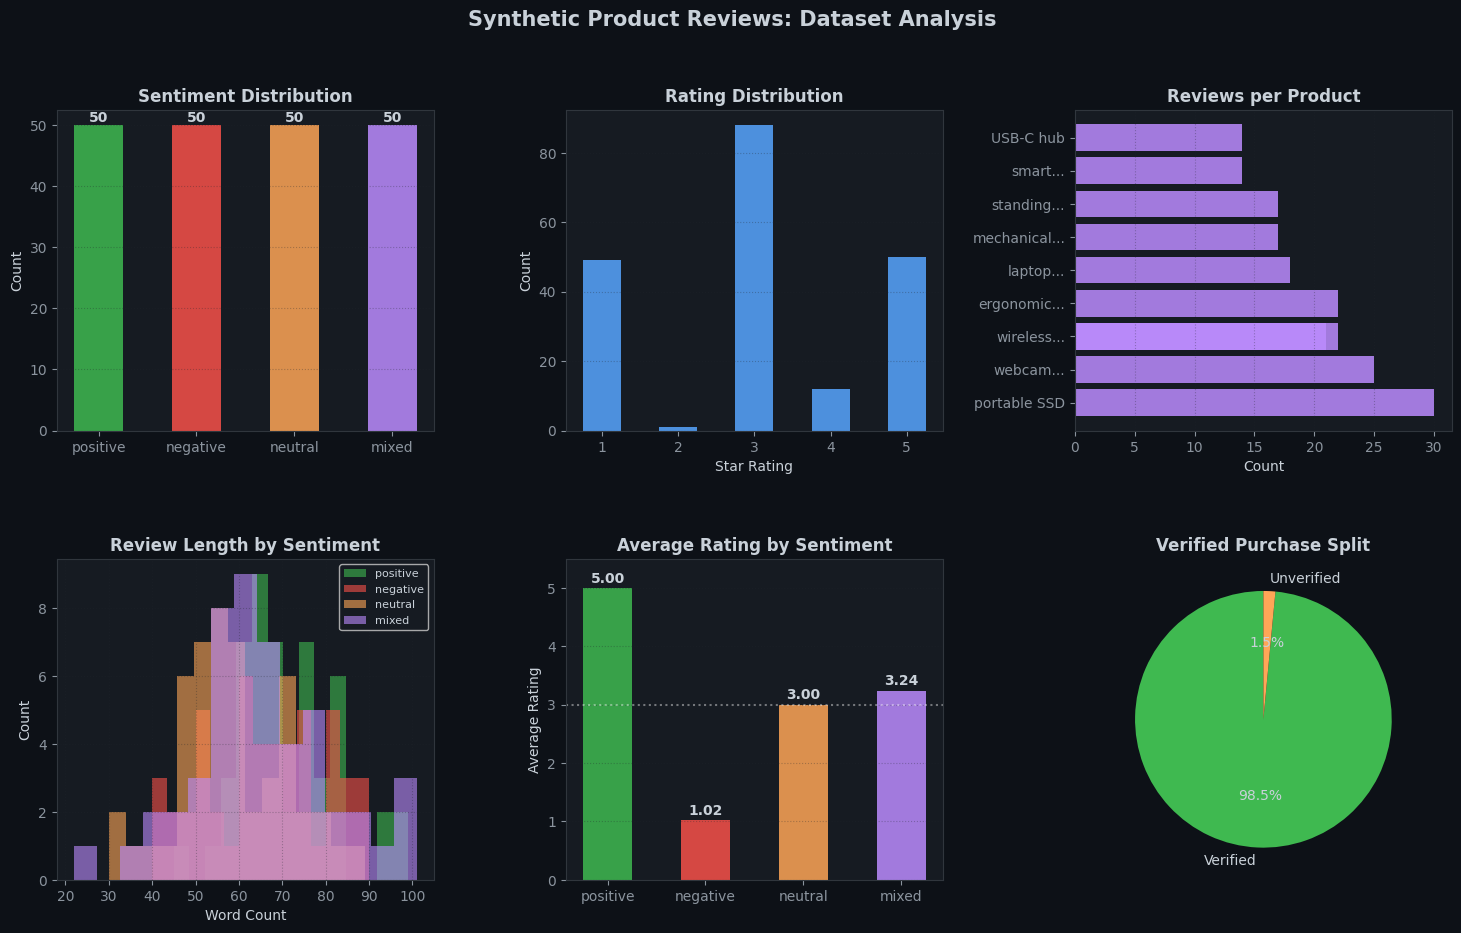

Reviews analysis saved.


In [7]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Synthetic Product Reviews: Dataset Analysis',
             fontsize=15, fontweight='bold', color='#c9d1d9')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

sent_colors = {'positive': C4, 'negative': C2,
               'neutral': C3, 'mixed': C5}

# Sentiment distribution
ax1 = fig.add_subplot(gs[0, 0])
sent_counts = reviews_df['sentiment'].value_counts()
bars = ax1.bar(sent_counts.index,
               sent_counts.values,
               color=[sent_colors[s] for s in sent_counts.index],
               alpha=0.85, width=0.5)
ax1.set_title('Sentiment Distribution', fontweight='bold')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, sent_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')

# Rating distribution
ax2 = fig.add_subplot(gs[0, 1])
rating_counts = reviews_df['rating'].value_counts().sort_index()
ax2.bar(rating_counts.index.astype(str),
        rating_counts.values,
        color=C1, alpha=0.85, width=0.5)
ax2.set_title('Rating Distribution', fontweight='bold')
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Count')
ax2.grid(True, alpha=0.3, axis='y')

# Product distribution
ax3 = fig.add_subplot(gs[0, 2])
prod_counts = reviews_df['product'].value_counts()
short_names = [p.split()[0] + '...' if len(p) > 12 else p
               for p in prod_counts.index]
ax3.barh(short_names, prod_counts.values,
         color=C5, alpha=0.85)
ax3.set_title('Reviews per Product', fontweight='bold')
ax3.set_xlabel('Count')
ax3.grid(True, alpha=0.3, axis='x')

# Review length distribution
ax4 = fig.add_subplot(gs[1, 0])
reviews_df['word_count'] = reviews_df['review'].str.split().str.len()
for sent in SENTIMENTS:
    subset = reviews_df[reviews_df['sentiment'] == sent]['word_count']
    ax4.hist(subset, bins=15, alpha=0.6,
             label=sent, color=sent_colors[sent])
ax4.set_title('Review Length by Sentiment', fontweight='bold')
ax4.set_xlabel('Word Count')
ax4.set_ylabel('Count')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Rating by sentiment
ax5 = fig.add_subplot(gs[1, 1])
avg_rating = reviews_df.groupby('sentiment')['rating'].mean().reindex(
    SENTIMENTS)
bars5 = ax5.bar(avg_rating.index, avg_rating.values,
                color=[sent_colors[s] for s in avg_rating.index],
                alpha=0.85, width=0.5)
ax5.set_ylim(0, 5.5)
ax5.set_title('Average Rating by Sentiment', fontweight='bold')
ax5.set_ylabel('Average Rating')
ax5.axhline(y=3, color='white', linestyle=':', alpha=0.4)
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, avg_rating.values):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontweight='bold')

# Verified purchase breakdown
ax6 = fig.add_subplot(gs[1, 2])
ver_counts = reviews_df['verified'].value_counts()
ax6.pie(ver_counts.values,
        labels=['Verified' if v else 'Unverified'
                for v in ver_counts.index],
        colors=[C4, C3], autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10})
ax6.set_title('Verified Purchase Split', fontweight='bold')

plt.savefig('reviews_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Reviews analysis saved.")

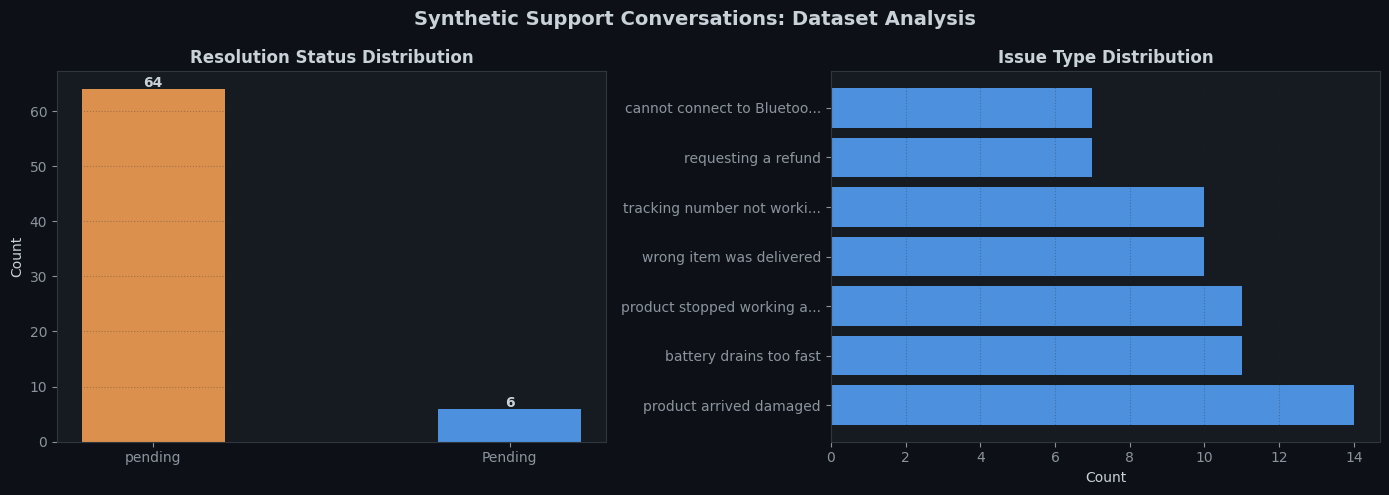

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthetic Support Conversations: Dataset Analysis',
             fontsize=14, fontweight='bold', color='#c9d1d9')

# Resolution distribution
ax = axes[0]
res_counts = support_df['resolution'].value_counts()
res_colors = {'resolved': C4, 'escalated': C2, 'pending': C3}
bars = ax.bar(res_counts.index, res_counts.values,
              color=[res_colors.get(r, C1) for r in res_counts.index],
              alpha=0.85, width=0.4)
ax.set_title('Resolution Status Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, res_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

# Issue distribution
ax2 = axes[1]
issue_counts = support_df['issue'].value_counts()
short_issues = [i[:25] + '...' if len(i) > 25 else i
                for i in issue_counts.index]
ax2.barh(short_issues, issue_counts.values,
         color=C1, alpha=0.85)
ax2.set_title('Issue Type Distribution', fontweight='bold')
ax2.set_xlabel('Count')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('support_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 6. Save Datasets

In [9]:
reviews_df.to_csv('synthetic_reviews.csv', index=False)
support_df.to_csv('synthetic_support.csv', index=False)

print("Datasets saved:")
print(f"  synthetic_reviews.csv  ({len(reviews_df)} rows)")
print(f"  synthetic_support.csv  ({len(support_df)} rows)")
print()
print("Sample reviews:")
for _, row in reviews_df.sample(3, random_state=42).iterrows():
    print(f"\n  Product:   {row['product']}")
    print(f"  Sentiment: {row['sentiment']}")
    print(f"  Rating:    {row['rating']}")
    print(f"  Review:    {row['review'][:100]}...")

Datasets saved:
  synthetic_reviews.csv  (200 rows)
  synthetic_support.csv  (70 rows)

Sample reviews:

  Product:   USB-C hub
  Sentiment: negative
  Rating:    1
  Review:    I recently purchased this USB-C hub and was disappointed to find that it only supported a few of my ...

  Product:   USB-C hub
  Sentiment: positive
  Rating:    5
  Review:    I recently purchased this USB-C hub and I'm blown away by its performance. The hub has easily allowe...

  Product:   wireless noise-cancelling headphones
  Sentiment: positive
  Rating:    5
  Review:    I recently purchased these wireless noise-cancelling headphones and I'm blown away by the sound qual...


---
## 7. Summary

In [10]:
print("=" * 58)
print("  TMD-03: Synthetic Text Generation · Summary")
print("=" * 58)
print(f"  Model used:               Mistral-7B-Instruct-v0.2")
print(f"  Quantization:             4-bit NF4")
print(f"  Product reviews generated: {len(reviews_df)}")
print(f"  Support conversations:     {len(support_df)}")
print(f"  Sentiment classes:         {reviews_df['sentiment'].nunique()}")
print(f"  Product categories:        {reviews_df['product'].nunique()}")
print(f"  Avg review length:         {reviews_df['word_count'].mean():.1f} words")
print("=" * 58)
print()
print("  Next: TMD-04 Image Augmentation Pipeline")
print()
print("  Handbook: Teaching Machines to Dream")
print("  Authors:  Aimal Khan · Hamza Raziq Khan")

  TMD-03: Synthetic Text Generation · Summary
  Model used:               Mistral-7B-Instruct-v0.2
  Quantization:             4-bit NF4
  Product reviews generated: 200
  Support conversations:     70
  Sentiment classes:         4
  Product categories:        10
  Avg review length:         65.2 words

  Next: TMD-04 Image Augmentation Pipeline

  Handbook: Teaching Machines to Dream
  Authors:  Aimal Khan · Hamza Raziq Khan


---

## Key Takeaways

1. A 7B parameter LLM fits on a single T4 GPU with 4-bit quantization using only 4GB VRAM
2. Structured system prompts with JSON schemas eliminate post-processing entirely
3. Controlling sentiment at generation time gives you a perfectly balanced dataset
4. 200 labeled reviews generated in under 20 minutes at zero annotation cost
5. The same pattern works for any text domain: legal documents, medical notes, news articles

### When to Use LLM Generation vs Augmentation

Use LLM generation when you need labeled data from scratch with no seed examples.
Use augmentation (back-translation, paraphrasing) when you already have some real data
and want to expand it while preserving the original style and domain.

---

*Part of the Teaching Machines to Dream handbook series.*  
*Aimal Khan · Hamza Raziq Khan · Peshawar, 2026*